In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os, datetime
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model
from tensorflow.keras import datasets, layers, models
from PIL import Image
import pydotplus
import pydot

In [15]:
# !pip install pydotplus pydot

In [3]:
import os

base_dir = r"D:\DeepFake-Image\real_vs_fake\real-vs-fake"

train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

In [4]:
scaled_train = ImageDataGenerator( rescale = 1.0/255. )
scaled_test = ImageDataGenerator( rescale = 1.0/255. )
scaled_valid = ImageDataGenerator( rescale = 1.0/255. )

In [6]:
scaled_train = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = scaled_train.flow_from_directory(
    train_dir,
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = scaled_train.flow_from_directory(
    train_dir,
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 80000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


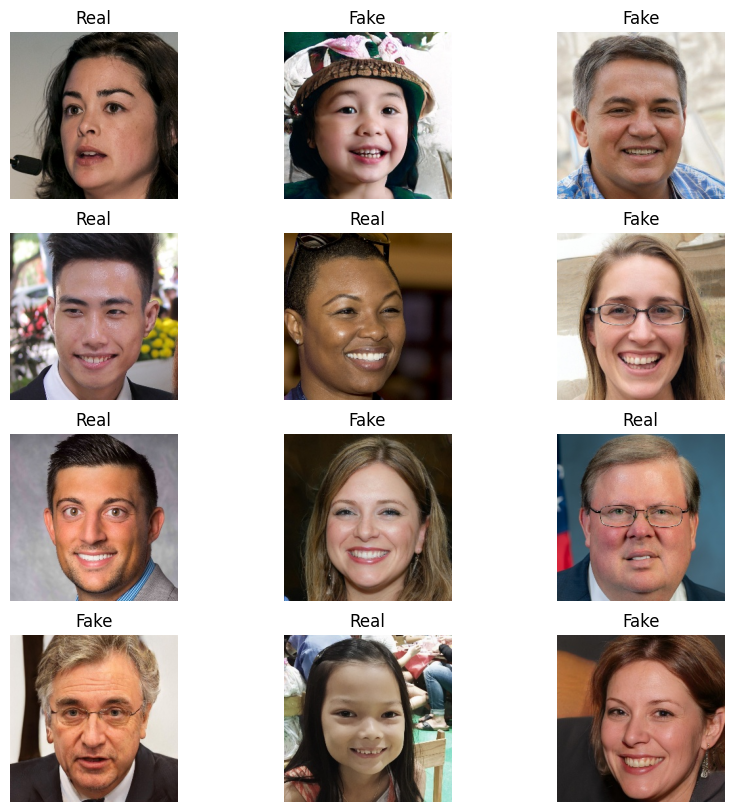

In [7]:
plt.figure(figsize=(10, 10))
for i in range(12):
    img, label = next(train_generator)
    ax = plt.subplot(4, 3, i + 1)
    plt.imshow(img[0])
    if(label[0] == 0.0):
        plt.title("Fake")
    else:
        plt.title("Real")
    plt.axis("off")

In [8]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(1064, activation= 'relu'))
model.add(layers.Dense(2, activation='softmax'))


In [9]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 62, 62, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 30, 30, 128)       0

In [10]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics = ['accuracy'])

In [11]:
%%time
history = model.fit(train_generator, validation_data = validation_generator, epochs = 10, validation_steps = 50, verbose=1)

Epoch 1/10


2500/2500 [==============================] - 2701s 1s/step - loss: 0.5164 - accuracy: 0.7448 - val_loss: 0.3790 - val_accuracy: 0.8288
Epoch 2/10
2500/2500 [==============================] - 2416s 966ms/step - loss: 0.2610 - accuracy: 0.8917 - val_loss: 0.2253 - val_accuracy: 0.9031
Epoch 3/10
2500/2500 [==============================] - 2095s 838ms/step - loss: 0.1182 - accuracy: 0.9545 - val_loss: 0.2108 - val_accuracy: 0.9175
Epoch 4/10
2500/2500 [==============================] - 2032s 813ms/step - loss: 0.0544 - accuracy: 0.9792 - val_loss: 0.2313 - val_accuracy: 0.9331
Epoch 5/10
2500/2500 [==============================] - 1955s 782ms/step - loss: 0.0375 - accuracy: 0.9865 - val_loss: 0.2086 - val_accuracy: 0.9400
Epoch 6/10
2500/2500 [==============================] - 1957s 783ms/step - loss: 0.0268 - accuracy: 0.9907 - val_loss: 0.2478 - val_accuracy: 0.9394
Epoch 7/10
2500/2500 [==============================] - 1894s 757ms/step - loss: 0.0230 - accuracy: 0.9919 

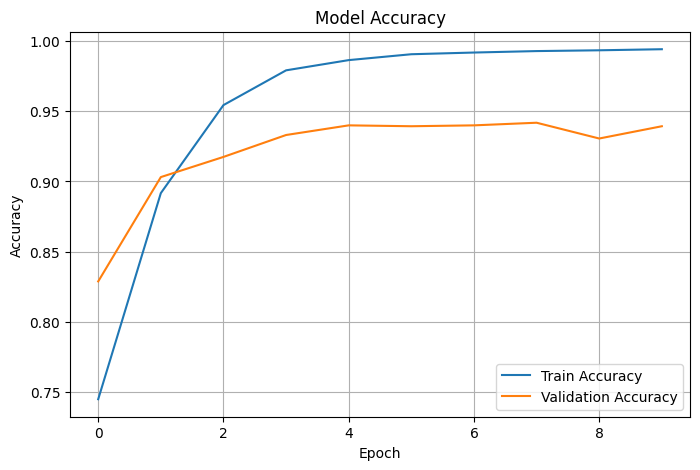

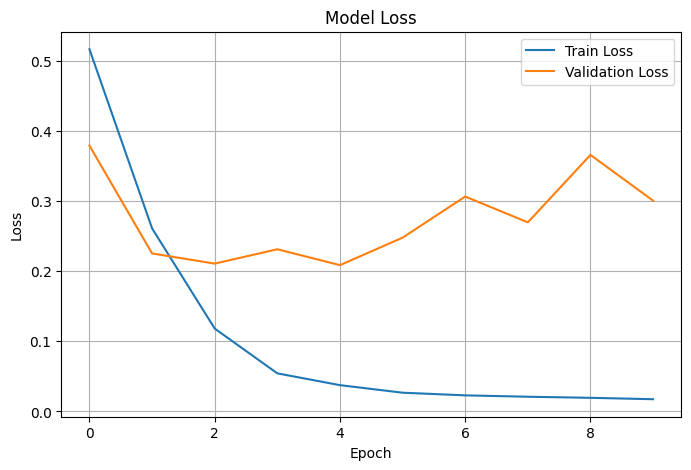

In [12]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Path (use your correct local path)
test_dir = r"D:\DeepFake-Image\real_vs_fake\real-vs-fake\test"

scaled_test = ImageDataGenerator(rescale=1./255)

test_generator = scaled_test.flow_from_directory(
    test_dir,
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 20000 images belonging to 2 classes.


In [16]:
test_loss, test_acc = model.evaluate(test_generator)

print(f"Test Accuracy: {test_acc * 100:.2f}%")

625/625 [==============================] - 217s 347ms/step - loss: 0.3245 - accuracy: 0.9399
Test Accuracy: 93.99%


In [17]:

class_names = ['fake', 'real']

In [19]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Load image (LOCAL PATH)
img_path = r"D:\DeepFake-Image\real_vs_fake\real-vs-fake\test\fake\0A266M95TD.jpg"

# Load and preprocess
test_image = image.load_img(img_path, target_size=(256, 256))
test_image = image.img_to_array(test_image) / 255.0
test_image = np.expand_dims(test_image, axis=0)

# Predict
result = model.predict(test_image)

# Class names
class_names = ['fake', 'real']

# Get prediction
predicted_class = class_names[np.argmax(result)]

# Confidence
confidence = np.max(result) * 100

print(f"Prediction: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

1/1 [==============================] - 0s 239ms/step
Prediction: fake
Confidence: 100.00%


In [20]:
import os

# Create models directory if it doesn't exist
save_dir = r"D:\DeepFake-Image\models"
os.makedirs(save_dir, exist_ok=True)

# Save in modern Keras format
model.save(os.path.join(save_dir, "deepfake_model.keras"))

# Save in HDF5 format
model.save(os.path.join(save_dir, "deepfake_model.h5"))

print("✅ Model saved successfully in both formats!")

c:\Users\Srinidhi\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


✅ Model saved successfully in both formats!


## Run the saved model on local machine.

In [21]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.preprocessing import image

In [22]:
# Load the saved model
model = tf.keras.models.load_model('D:\DeepFake-Image\models\deepfake_model.keras')


In [23]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 62, 62, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 30, 30, 128)       0

In [24]:
class_names = ['fake', 'real']

In [25]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Local image path (FIX THIS PATH if needed)
img_path = r"D:\DeepFake-Image\real_vs_fake\real-vs-fake\test\fake\0BJ8FHDRCL.jpg"

# Load image
test_image = image.load_img(img_path, target_size=(256, 256))

# Convert to array
test_image = image.img_to_array(test_image)

# Normalize (IMPORTANT)
test_image = test_image / 255.0

# Add batch dimension
test_image = np.expand_dims(test_image, axis=0)

# Predict
result = model.predict(test_image)

# Class labels
class_names = ['fake', 'real']

# Get result
confidence = np.max(result) * 100
prediction = class_names[np.argmax(result)]

print("🔍 Deepfake Detection Result")
print(f"Prediction: {prediction.upper()}")
print(f"Confidence: {confidence:.2f}%")

1/1 [==============================] - 0s 257ms/step
🔍 Deepfake Detection Result
Prediction: FAKE
Confidence: 100.00%


In [26]:
print(
    "This image is {:.2f} percentage {}."
    .format(100 * np.max(result), class_names[np.argmax(result)])
)

This image is 100.00 percentage fake.
